<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/MarketMicrostructure/MarketMicrostructure/Order_Book_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import dataclasses
import time
import enum
import bisect
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import List, Optional

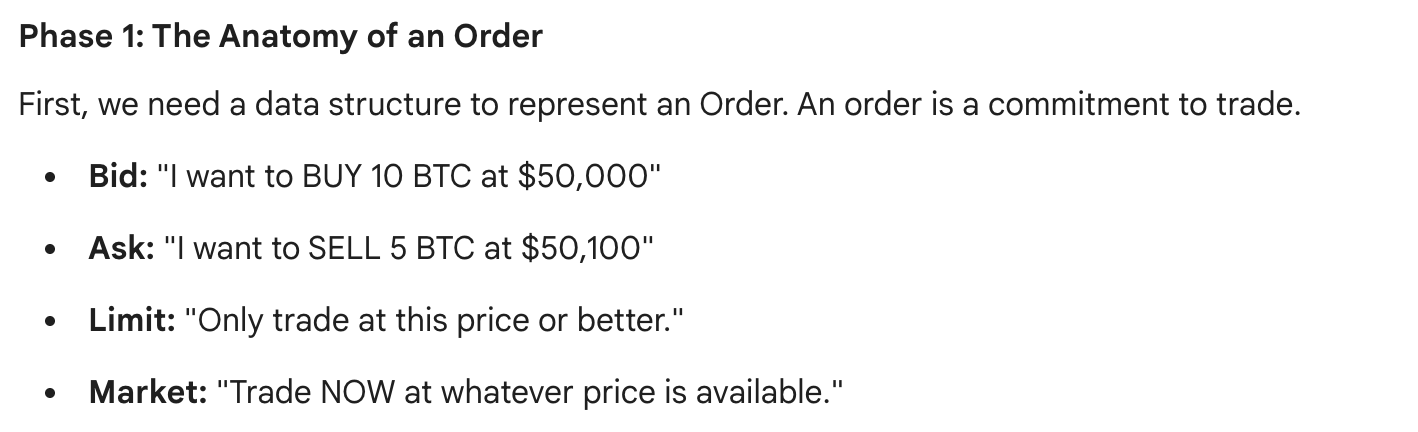

In [3]:
# --- 1. CORE DATA STRUCTURES ---

class Side(enum.Enum):
    BUY = 1
    SELL = 2

class OrderType(enum.Enum):
    LIMIT = 1
    MARKET = 2

@dataclasses.dataclass
class Order:
    order_id: int
    side: Side
    price: float        # 0.0 for Market Orders (conceptually)
    quantity: float
    timestamp: float    # For Time-Priority matching
    order_type: OrderType

    def __post_init__(self):
        # We handle float precision for prices by rounding to 2 decimals for this sim
        self.price = round(self.price, 2)

@dataclasses.dataclass
class Trade:
    timestamp: float
    price: float
    quantity: float
    maker_order_id: int
    taker_order_id: int
    side: Side # The side of the AGGRESSOR (Taker)

print("✅ Phase 1: Order structures defined.")

✅ Phase 1: Order structures defined.


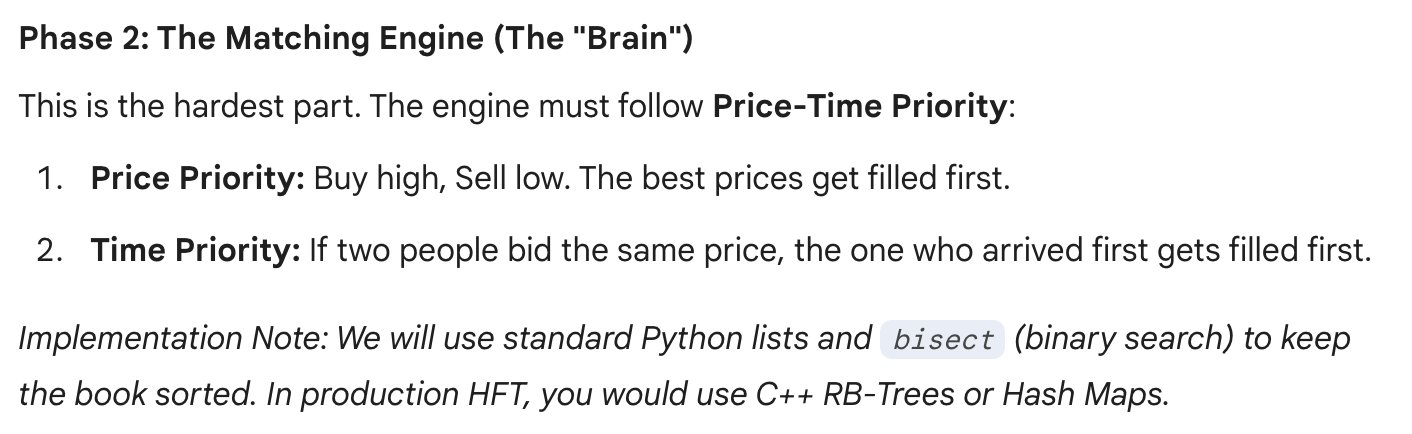

In [4]:
class OrderBook:
    def __init__(self):
        # Bids: Sorted Descending (Highest buy price is best)
        # Asks: Sorted Ascending (Lowest sell price is best)
        self.bids: List[Order] = []
        self.asks: List[Order] = []
        self.trades: List[Trade] = []
        self.order_map = {} # Quick lookup for cancellations
        self.current_time = 0.0

    def add(self, order: Order):
        self.order_map[order.order_id] = order

        # 1. MATCHING LOGIC
        if order.order_type == OrderType.MARKET:
            self._match_market_order(order)
        else:
            # Try to match Limit Order immediately (Crossing the spread)
            if order.side == Side.BUY:
                if self.asks and order.price >= self.asks[0].price:
                    self._match_limit_order(order, self.asks)
                else:
                    self._insert_bid(order)
            else: # SELL
                if self.bids and order.price <= self.bids[0].price:
                    self._match_limit_order(order, self.bids)
                else:
                    self._insert_ask(order)

    def _match_market_order(self, taker_order):
        # Determine which side to match against
        book_side = self.asks if taker_order.side == Side.BUY else self.bids

        while taker_order.quantity > 0 and book_side:
            best_order = book_side[0]
            trade_qty = min(taker_order.quantity, best_order.quantity)
            trade_price = best_order.price # Market order takes the Maker's price

            self._execute_trade(taker_order, best_order, trade_qty, trade_price)

            # Cleanup
            if best_order.quantity <= 0:
                book_side.pop(0) # Remove filled order
                del self.order_map[best_order.order_id]

    def _match_limit_order(self, taker_order, book_side):
        # Similar to market match, but constrained by price
        # Limit BUY matches against ASKS (book_side)
        while taker_order.quantity > 0 and book_side:
            best_order = book_side[0]

            # Check price constraint
            if taker_order.side == Side.BUY and best_order.price > taker_order.price:
                break
            if taker_order.side == Side.SELL and best_order.price < taker_order.price:
                break

            trade_qty = min(taker_order.quantity, best_order.quantity)
            trade_price = best_order.price # Maker dictates price

            self._execute_trade(taker_order, best_order, trade_qty, trade_price)

            if best_order.quantity <= 0:
                book_side.pop(0)
                del self.order_map[best_order.order_id]

        # If not fully filled, add remainder to book
        if taker_order.quantity > 0:
            if taker_order.side == Side.BUY:
                self._insert_bid(taker_order)
            else:
                self._insert_ask(taker_order)

    def _execute_trade(self, taker, maker, qty, price):
        taker.quantity -= qty
        maker.quantity -= qty
        self.trades.append(Trade(
            timestamp=time.time(), price=price, quantity=qty,
            maker_order_id=maker.order_id, taker_order_id=taker.order_id,
            side=taker.side
        ))

    def _insert_bid(self, order):
        # Bids sorted DESCENDING (Highest Price First)
        # We assume price-time priority. Since this list is sorted by price,
        # we find the correct position. For same price, earlier time is first.
        # Python's list sort is stable, but bisect isn't key-aware in older versions.
        # We'll use a linear scan for simplicity in tutorial (O(N)),
        # but binary search (O(logN)) is used in HFT.

        # Simple Linear Insert for tutorial clarity
        index = 0
        for i, o in enumerate(self.bids):
            if order.price > o.price: # Better price
                index = i
                break
            elif order.price == o.price: # Same price, check time (should go after)
                continue
            else: # Worse price
                index = i + 1

        self.bids.insert(index, order)

    def _insert_ask(self, order):
        # Asks sorted ASCENDING (Lowest Price First)
        index = len(self.asks)
        for i, o in enumerate(self.asks):
            if order.price < o.price: # Better price
                index = i
                break
            elif order.price == o.price:
                continue
        self.asks.insert(index, order)

    def get_best_bid_ask(self):
        bb = self.bids[0].price if self.bids else None
        ba = self.asks[0].price if self.asks else None
        return bb, ba

print("✅ Phase 2: Matching Engine Logic built.")

✅ Phase 2: Matching Engine Logic built.


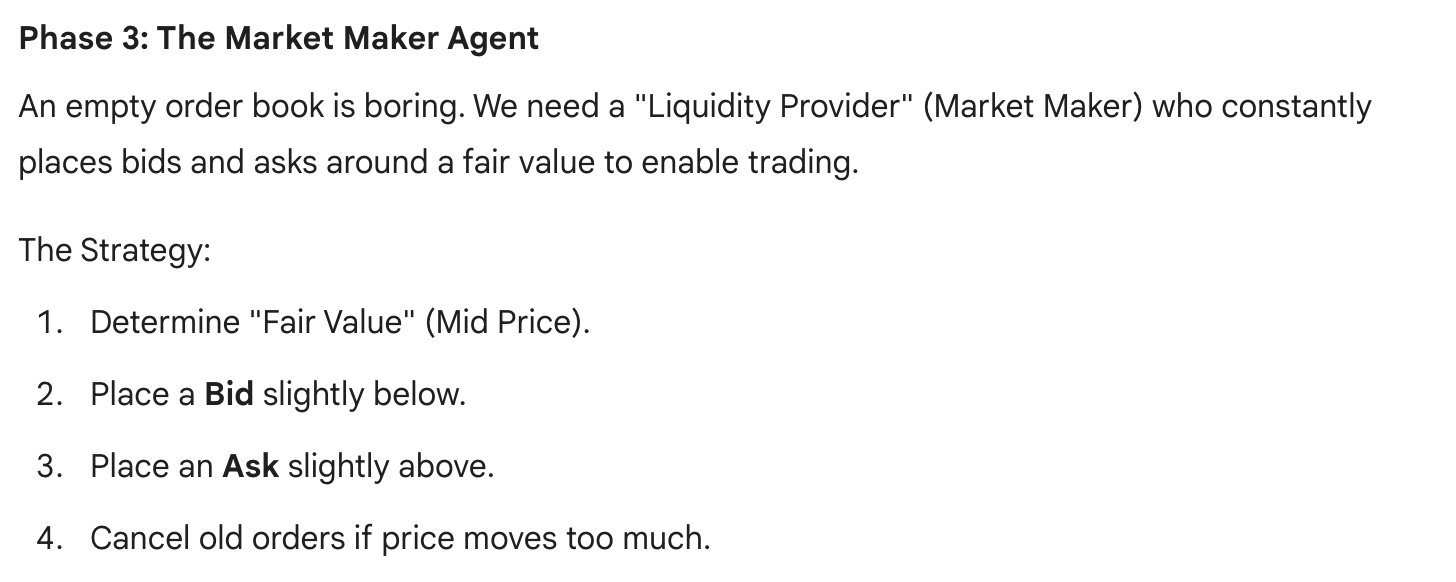

In [5]:
class MarketMaker:
    def __init__(self, env_book, initial_price=100.0):
        self.book = env_book
        self.fair_price = initial_price
        self.spread = 0.50 # $0.50 spread
        self.orders = []
        self.current_id = 1000

    def update(self):
        # 1. Simulate Price Random Walk (Geometric Brownian Motion Lite)
        shock = np.random.normal(0, 0.1)
        self.fair_price += shock

        # 2. Clear old orders (Simplification: Cancel all, replace)
        # In real HFT, you modify existing orders to save latency
        for o in self.orders:
            # We would technically remove from book here, but for sim we just ignore old ones
            # or rely on the book clearing matches.
            # To keep tutorial simple, we won't implement explicit "cancel" logic
            # but rather flood the book with new liquidity.
            pass

        # 3. Place New Quotes
        bid_price = self.fair_price - (self.spread / 2)
        ask_price = self.fair_price + (self.spread / 2)

        self.current_id += 1
        bid = Order(self.current_id, Side.BUY, bid_price, 10.0, time.time(), OrderType.LIMIT)
        self.book.add(bid)

        self.current_id += 1
        ask = Order(self.current_id, Side.SELL, ask_price, 10.0, time.time(), OrderType.LIMIT)
        self.book.add(ask)

print("✅ Phase 3: Market Maker Agent ready.")

✅ Phase 3: Market Maker Agent ready.


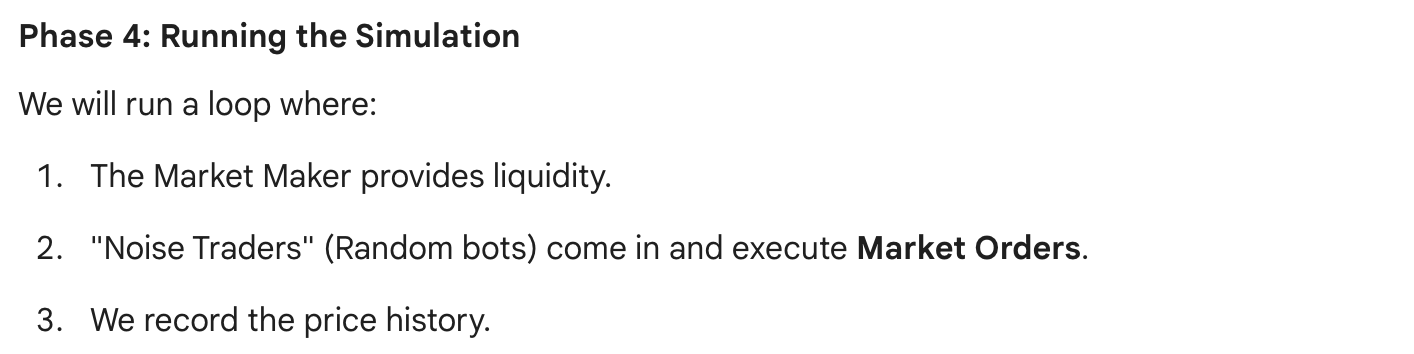

In [6]:
book = OrderBook()
mm = MarketMaker(book)

history_price = []
history_times = []

# --- SIMULATION LOOP ---
print("🚀 Starting Market Simulation...")
start_time = time.time()

for t in range(500):
    # 1. Market Maker acts
    mm.update()

    # 2. Random Noise Trader acts (Takes liquidity)
    if np.random.rand() < 0.3: # 30% chance of a trade occurring
        side = Side.BUY if np.random.rand() > 0.5 else Side.SELL
        quantity = np.random.randint(1, 5)

        market_order = Order(
            order_id=t,
            side=side,
            price=0.0,
            quantity=quantity,
            timestamp=time.time(),
            order_type=OrderType.MARKET
        )
        book.add(market_order)

    # 3. Record Data
    bb, ba = book.get_best_bid_ask()
    if bb and ba:
        mid_price = (bb + ba) / 2
        history_price.append(mid_price)
        history_times.append(t)

print(f"✅ Simulation Complete. Total Trades: {len(book.trades)}")

🚀 Starting Market Simulation...
✅ Simulation Complete. Total Trades: 632


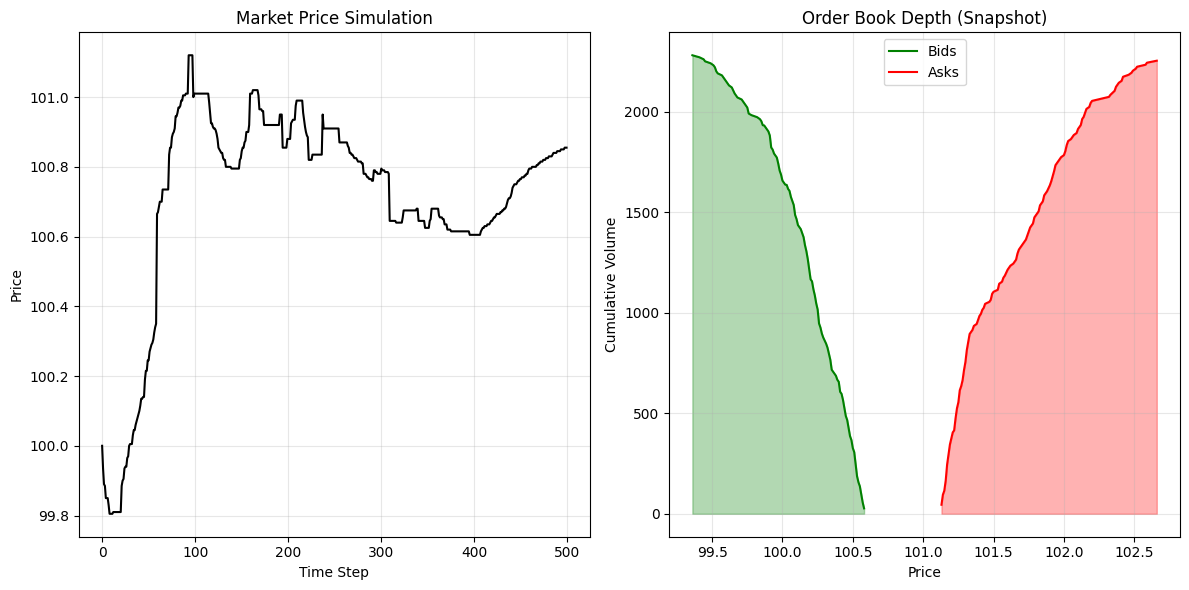

In [7]:
# --- PLOT 1: PRICE HISTORY ---
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_times, history_price, label="Mid Price", color='black')
# Plot Executed Trades
trade_times = [i for i in range(len(book.trades))] # Approximation for x-axis
trade_prices = [t.price for t in book.trades]
trade_colors = ['green' if t.side == Side.BUY else 'red' for t in book.trades]
# We plot trades as scatter points
# Note: aligning trade times to sim steps exactly requires tracking step index in Trade object
# We skip exact alignment for brevity, just showing price path.
plt.title("Market Price Simulation")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)

# --- PLOT 2: DEPTH CHART (SNAPSHOT) ---
plt.subplot(1, 2, 2)

# Aggregate Buy Volume
bids_prices = [o.price for o in book.bids]
bids_vol = [o.quantity for o in book.bids]
# Cumulative sum for depth
bids_df = pd.DataFrame({'price': bids_prices, 'vol': bids_vol})
bids_df = bids_df.groupby('price').sum().reset_index().sort_values('price', ascending=False)
bids_df['cum_vol'] = bids_df['vol'].cumsum()

# Aggregate Sell Volume
asks_prices = [o.price for o in book.asks]
asks_vol = [o.quantity for o in book.asks]
asks_df = pd.DataFrame({'price': asks_prices, 'vol': asks_vol})
asks_df = asks_df.groupby('price').sum().reset_index().sort_values('price', ascending=True)
asks_df['cum_vol'] = asks_df['vol'].cumsum()

# Plot Green Wall (Bids)
plt.plot(bids_df['price'], bids_df['cum_vol'], color='green', label='Bids')
plt.fill_between(bids_df['price'], bids_df['cum_vol'], color='green', alpha=0.3)

# Plot Red Wall (Asks)
plt.plot(asks_df['price'], asks_df['cum_vol'], color='red', label='Asks')
plt.fill_between(asks_df['price'], asks_df['cum_vol'], color='red', alpha=0.3)

plt.title("Order Book Depth (Snapshot)")
plt.xlabel("Price")
plt.ylabel("Cumulative Volume")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()